In [1]:
import utils
import torch
from PIL import Image
import matplotlib.pyplot as plt

model = utils.load_model()

layers = {
    "Shallow (layer1)": model.layer1,
    "Deep (layer4)": model.layer4,
}

print("Loaded model:", type(model).__name__)

Loaded model: ResNet


In [2]:
img_a = Image.open("assets/bicycle.jpg").convert("RGB")
img_b = Image.open("assets/dog.jpg").convert("RGB")

In [3]:
layer_name = "Shallow (layer1)"
# layer_name = "Deep (layer4)"
layer = layers[layer_name]
print("CAM layer:", layer_name)

CAM layer: Shallow (layer1)


In [10]:
def render_vg_panel(pil_img, title="Image"):
    x = utils.pil_to_tensor(pil_img)

    plt.figure(figsize=(4,4))
    plt.imshow(pil_img); plt.axis("off"); plt.title(f"{title}")
    plt.show()

    preds = utils.predict_topk(model, x, k=5)
    print(title, "Top-k (class idx, prob):", preds)

    try:
        cam_img = utils.gradcam_overlay(model, x, pil_img, layer)
        plt.figure(figsize=(4,4))
        plt.imshow(cam_img); plt.axis("off"); plt.title(f"{title}: Grad-CAM on {layer_name}")
        plt.show()
    except Exception as e:
        print("Grad-CAM failed:", e)

    acts = utils.capture_activations(model, x, layers)
    for lname in layers.keys():
        act = acts[lname]
        print(f"{title} {lname} act shape:", tuple(act.shape))

        mean_img = utils.activation_mean(act).resize((224,224))
        plt.figure(figsize=(4,4))
        plt.imshow(mean_img, cmap="gray"); plt.axis("off")
        plt.title(f"{title}: {lname} mean")
        plt.show()

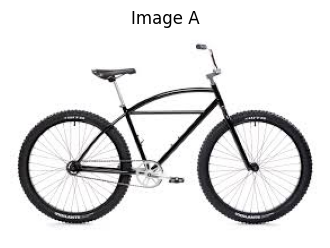

Image A Top-k (class idx, prob): [(671, 0.8487579822540283), (444, 0.12972109019756317), (880, 0.01708471216261387), (870, 0.003931188955903053), (665, 0.00036816467763856053)]


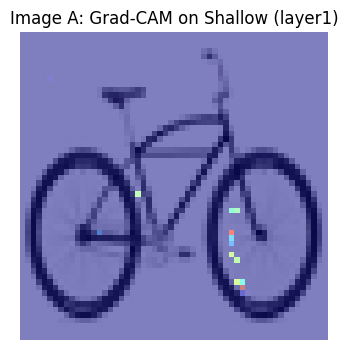

Image A Shallow (layer1) act shape: (1, 64, 56, 56)


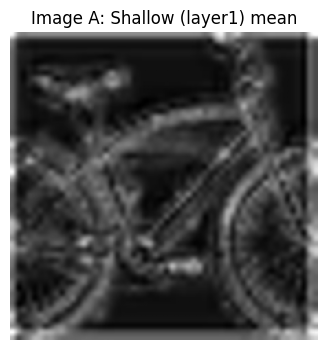

Image A Deep (layer4) act shape: (1, 512, 7, 7)


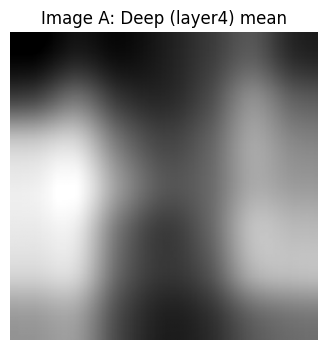

In [11]:
render_vg_panel(img_a, "Image A")

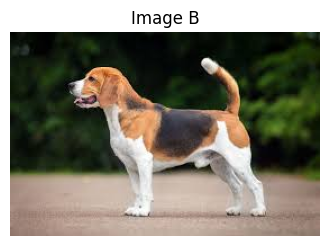

Image B Top-k (class idx, prob): [(167, 0.8440621495246887), (166, 0.11453748494386673), (162, 0.03439406305551529), (161, 0.005759193561971188), (163, 0.00047840672777965665)]


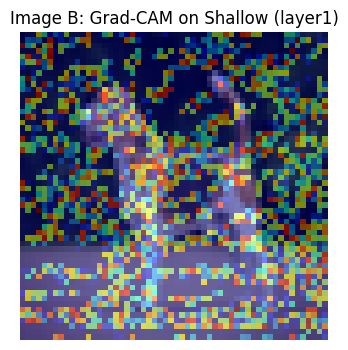

Image B Shallow (layer1) act shape: (1, 64, 56, 56)


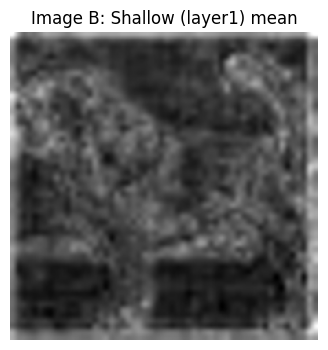

Image B Deep (layer4) act shape: (1, 512, 7, 7)


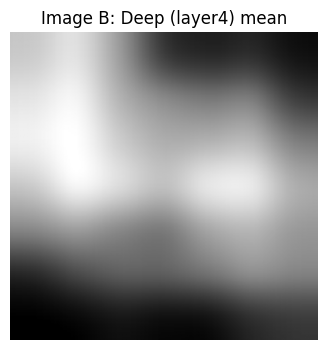

In [13]:
render_vg_panel(img_b, "Image B")

Channel count for selected layer: 64


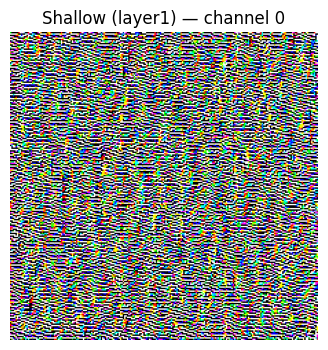

Last 10 objective values: [17.126073837280273, 17.128618240356445, 17.13111686706543, 17.133636474609375, 17.136133193969727, 17.13858985900879, 17.141050338745117, 17.143463134765625, 17.145832061767578, 17.148195266723633]


In [12]:
dummy = torch.zeros(1, 3, 224, 224, device=next(model.parameters()).device)
dummy_acts = utils.capture_activations(model, dummy, {"selected": layer})["selected"]
ch_count = int(dummy_acts.shape[1])
print("Channel count for selected layer:", ch_count)

ch = 0
out_img, hist = utils.activation_maximization(
    model,
    layer,
    channel=ch,
    steps=200,
    lr=0.08,
    l2_weight=1e-4,
    tv_weight=1e-4,
    seed=0,
)

plt.figure(figsize=(4,4))
plt.imshow(out_img); plt.axis("off")
plt.title(f"{layer_name} — channel {ch}")
plt.show()

print("Last 10 objective values:", hist[-10:])


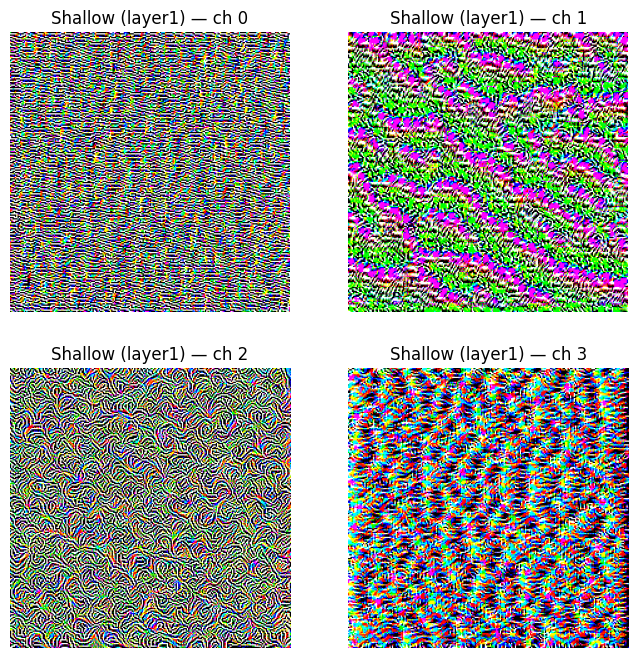

In [8]:
ch_list = [0, 1, 2, 3]
imgs = []
for i, cidx in enumerate(ch_list):
    im, _ = utils.activation_maximization(
        model,
        layer,
        channel=int(cidx),
        steps=200,
        lr=0.08,
        l2_weight=1e-4,
        tv_weight=1e-4,
        seed=0 + i,
    )
    imgs.append((cidx, im))

plt.figure(figsize=(8,8))
for i, (cidx, im) in enumerate(imgs, 1):
    plt.subplot(2,2,i)
    plt.imshow(im); plt.axis("off")
    plt.title(f"{layer_name} — ch {cidx}")
plt.show()
